# Bigram language model

This notebook contains my notes (ah, [hello](www.bazcuervo.net)) from Karpathy's [second lesson](https://www.youtube.com/watch?v=PaCmpygFfXo) from [*Neural Networks: Zero to Hero*](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ).

It's more exhaustive than the [notebook](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part1_bigrams.ipynb) that he has uploaded, given that here I reproduce all the steps in the tutorial instead of just building the final result (the process is quite iterative).

Let's first load and explore our dataset of names.

In [1]:
words = open("names.txt", "r").read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

Into a single word (e.g. `isabella`), there's so much information packed for our neural net:

- the character `i` can begin a word
- `s` can appear after just `i`
- `a` tends to appear after `is`
- (...)
- and that when we have `isabella`, the word is likely to end

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
for w in words:
    if len(w) == 15:
        print(w)

muhammadibrahim
muhammadmustafa


---

A **bigram** is a two-character pair (e.g. `<start>e`, `em`, `mm`, etc.).

A **bigram** language model is a language model that only looks at a single character in order to predict the next one , disregarding the position that that character is in (i.e. it predicts bigrams). It's simple & weak but effective for learning.

In order to predict a given character at position `i`, it only looks at the character at the `i-1` position and disregards all of the previous information that we have at `i-(1+n), n=1,2,3,...`.

Let's explore some bigrams here:

In [7]:
for w in words[:3]:
    # this works because zip here takes two iterables and pairs up their
    # elements position-by-position, stopping when the shorter one runs out.
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a
o l
l i
i v
v i
i a
a v
v a


We can count how many times each bigram occurs, and that contains useful information for our model. 

We'll also include two special characters that mark the beginning and end of the words, as they are important for the model.

In [8]:
b = {}
for w in words:
    characters = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(characters, characters[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


We can sort them by highest appearance with a neat trick:

In [9]:
# sorted by default takes the first item of a tuple, so we need to specify
# by which key to sort (i.e. a function to execute over each item that will
# determine the "key" by which order that item in the list).
sorted(b.items(), key = lambda kv: kv[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

This is representation (a dictionary) inconvenient. Let's better use a two dimensional matrix (a **tensor**) in which both rows and columns represent characters, so that the `[i,j]` position represents how many times the character `i` follows to `j` (or viceversa, I don't know the convention).

In [10]:
import torch

In [11]:
a = torch.zeros((3, 5), dtype=torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [12]:
a[1, 3] = 1

In [13]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

---

Okay, now let's build our matrix: how many *unique* characters do we have?

In [14]:
len(set(''.join(words)))

26

to which we have to sum 2, for the special characters for beginning and end of a word.

In [15]:
unique_chars = sorted(list(set(''.join(words))))

and we will need a **mapping** of indices to characters.

In [16]:
# character_to_index
ctoi = {c:i for i,c in enumerate(unique_chars)}
# and let's add our two special characters
ctoi['<S>'] = 26
ctoi['<E>'] = 27

Building now our matrix:

In [17]:
N = torch.zeros((28, 28), dtype=torch.int32)

for w in words:
    word_chars = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(word_chars, word_chars[1:]):
        i = ctoi[ch1]
        j = ctoi[ch2]
        N[i, j] += 1

In [18]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

Awesome, now let's try to visualize that in some meaningful ways.

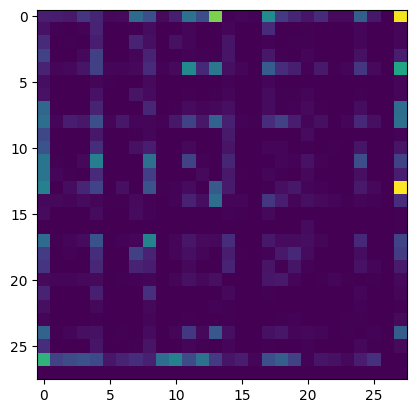

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

Let's improve our visualization. We'll need an inverted mapping of `ctoi` (character to index), i.e. `index_to_character`.

In [20]:
itoc = {i:s for s,i in ctoi.items()}

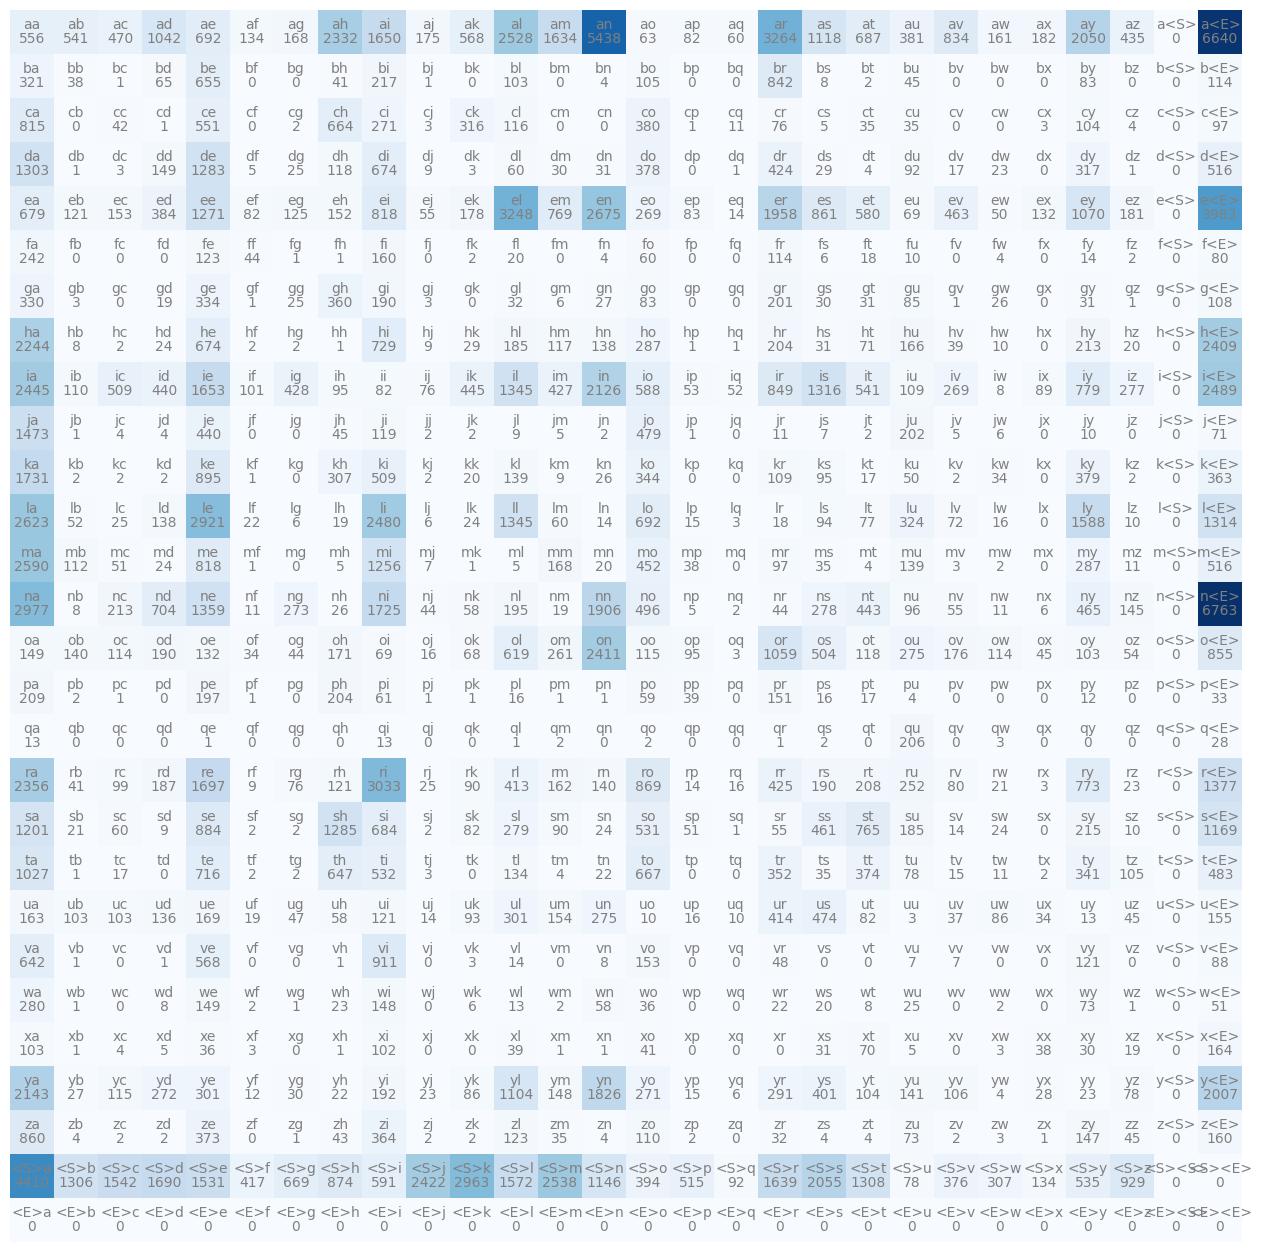

In [21]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        bigram = itoc[i] + itoc[j]
        plt.text(j, i, bigram, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off');

Nice! But we can see here that we're not very clever with how we handle the `<S>` and the `<E>` characters. We'll never encounter any `x<S>` or `<E>x` for any character `x`, obviously, so we're wasting space in our matrix.

We'll also change how we name them for the sake of simplicity, and given that we're developing a **bigram** language model we can safely use the same special token (which will be `.`) for both the start and the finish.

Let's redo the process with this new approach in mind:

In [22]:
# let's have our special char at the first place, so we have to
#  offset the characters by one position
ctoi = {c:i+1 for i,c in enumerate(unique_chars)}
ctoi['.'] = 0
itoc = {i:s for s,i in ctoi.items()}

In [23]:
# initialize the matrix
N = torch.zeros((28, 28), dtype=torch.int32)

# count
for w in words:
    word_chars = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(word_chars, word_chars[1:]):
        i = ctoi[ch1]
        j = ctoi[ch2]
        N[i, j] += 1

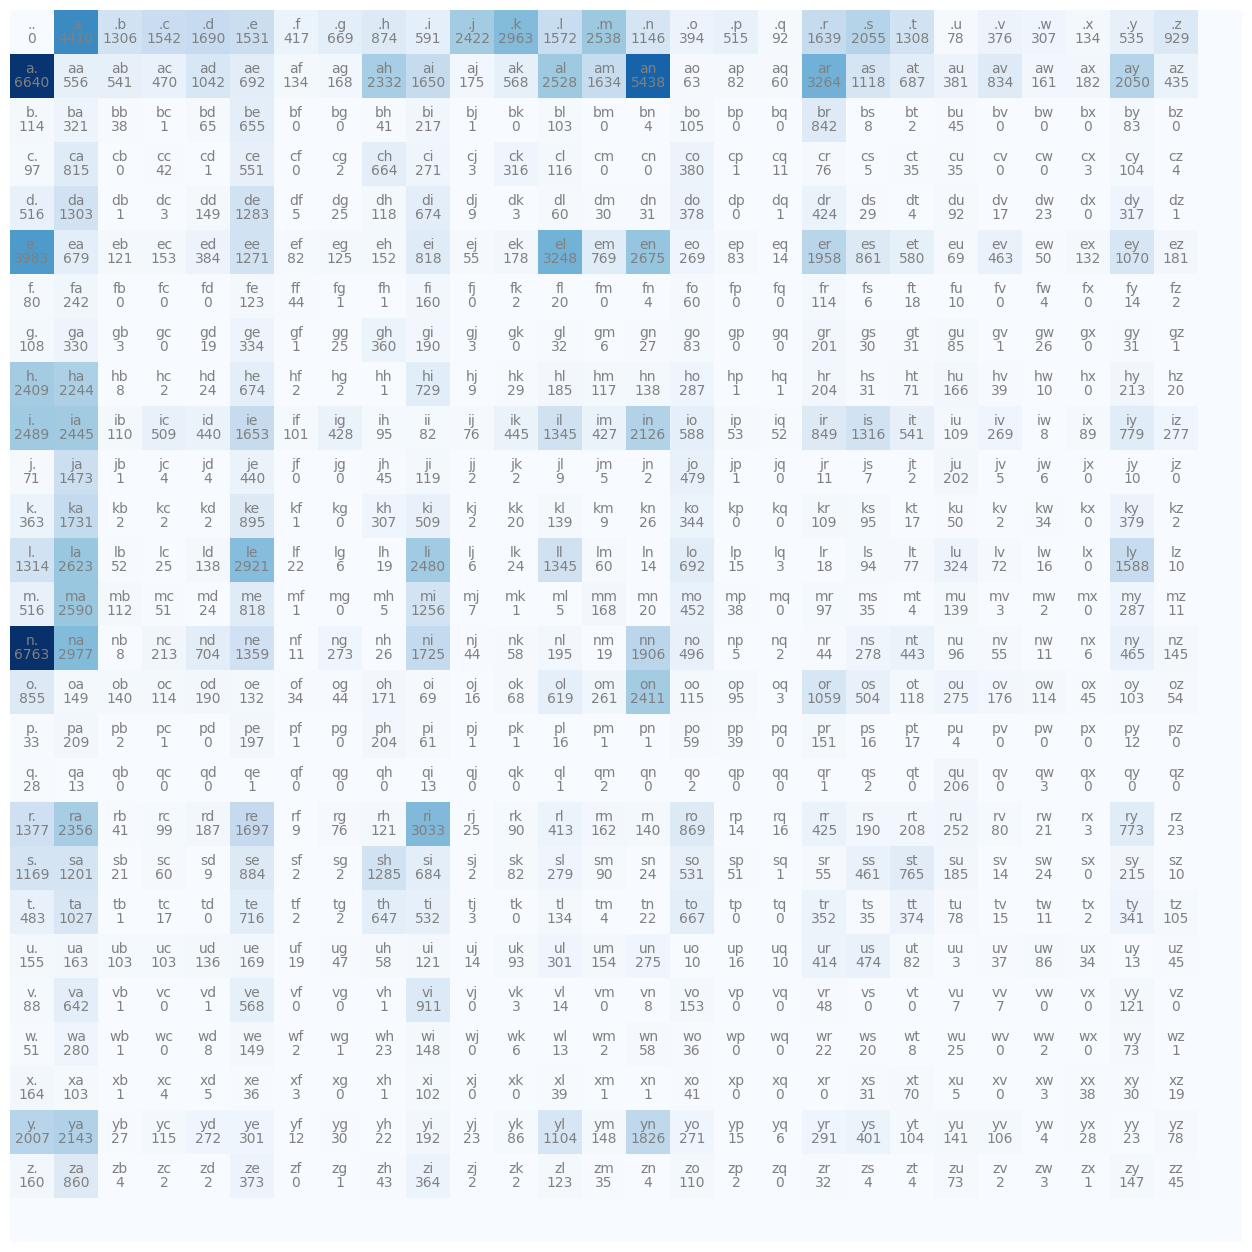

In [24]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        bigram = itoc[i] + itoc[j]
        plt.text(j, i, bigram, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off');

Nice. The first row & column represents word startings and word endings, respectively.  
*(timestamp: 24:15)*